## DATA 622 - Assignment 2: 

### Introduction
Compare the results with the results from previous homework.

Read the following articles:
- https://www.hindawi.com/journals/complexity/2021/5550344/
- https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8137961/

Search for academic content (at least 3 articles) that compare the use of decision trees vs SVMs in your current area of expertise.

Perform an analysis of the dataset used in Homework #2 using the SVM algorithm. Compare the results with the results from previous homework. Answer questions, such as:
- Which algorithm is recommended to get more accurate results?
- Is it better for classification or regression scenarios?
- Do you agree with the recommendations?
- Why?

In [1]:
## load modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

## load decision tree modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

## Load Data

In [2]:
bank_full_url = 'https://raw.githubusercontent.com/eddiexunyc/ml_big_data_work/refs/heads/main/Assignment%201/bank/bank-full.csv'
bank_full = pd.read_csv(bank_full_url, sep=';')
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [3]:
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Pre-Processing

In [4]:
# convert the target variable to binary
bank_full['y'] = bank_full['y'].map({'yes': 1, 'no': 0})

# encode the categorical variables
cat_cols = bank_full.select_dtypes(include='object').columns
bank_encoded = pd.get_dummies(bank_full, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", bank_encoded.shape)

Encoded dataset shape: (45211, 43)


In [5]:
bank_encoded

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45207,71,1729,17,456,2,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45208,72,5715,17,1127,5,184,3,1,0,0,...,0,0,0,0,1,0,0,0,1,0
45209,57,668,17,508,4,-1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1


In [6]:
# add constant before the VIF calculation
bank_feature = bank_encoded.drop('y', axis=1)
bank_y = bank_encoded['y']


In [7]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(bank_feature, bank_y, test_size=0.2, random_state=42, stratify=bank_y)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (36168, 42) | Test size: (9043, 42)


### Decision Tree

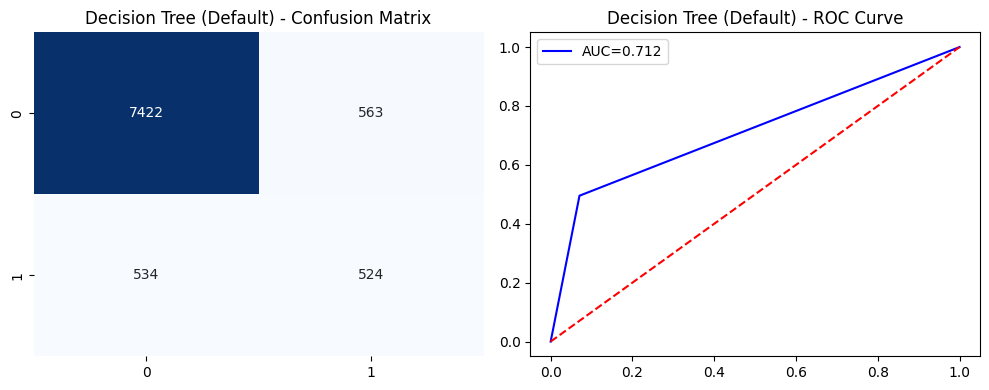

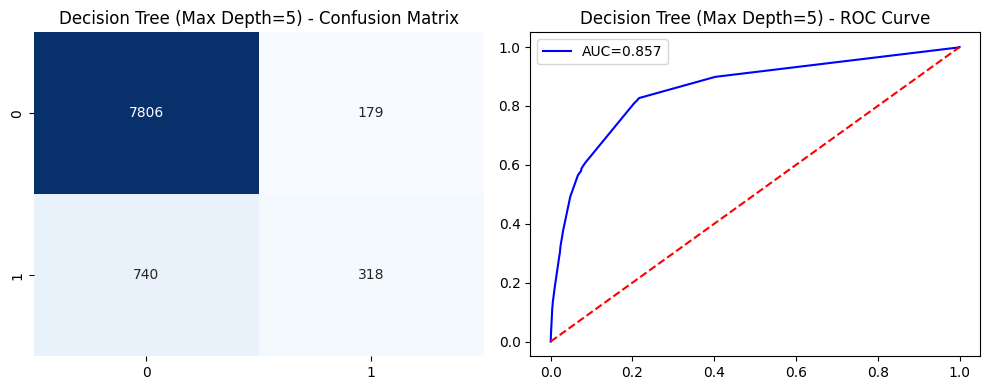

,Model,Accuracy,Precision,Recall,F1,AUC
0,Decision Tree (Default),0.878691,0.482061,0.495274,0.488578,0.712383
1,Decision Tree (Max Depth=5),0.898374,0.639839,0.300567,0.409003,0.857178


In [8]:
# experiment 1: to see the impact of overfitting and generalization from the controlling tree depth
dt_default = DecisionTreeClassifier(random_state=42)
dt_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)

models = [("Decision Tree (Default)", dt_default),
          ("Decision Tree (Max Depth=5)", dt_depth5)]

results_dt = []

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_dt.append([name, acc, prec, rec, f1, auc])
    
    # Visual
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.subplot(1,2,2)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='blue')
    plt.plot([0,1],[0,1],'r--')
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

pd.DataFrame(results_dt, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])



{'Accuracy': 0.8984850160345018, 'Precision': 0.6263537906137184, 'Recall': 0.3279773156899811, 'F1': 0.4305210918114144, 'AUC': 0.849648620463937}


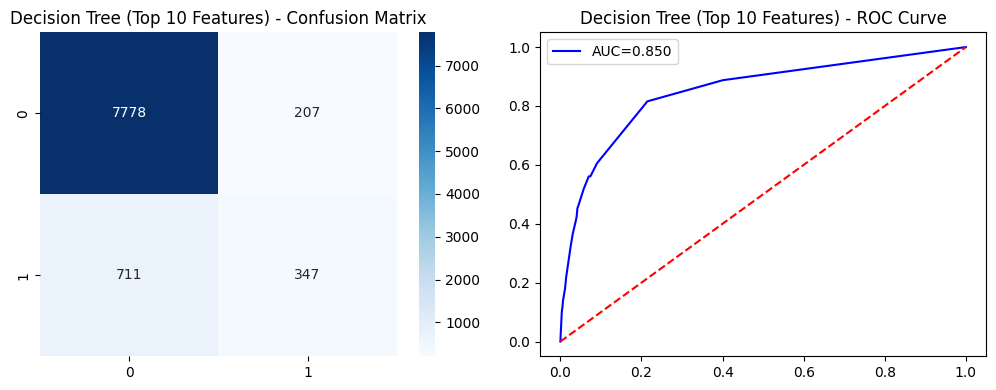

In [9]:
# experiment 2: to see the impact of Top 10 Important Features while simplifying the model
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

feat_imp = pd.Series(dt_full.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10).index

dt_top10 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_top10.fit(X_train[top10], y_train)

y_pred = dt_top10.predict(X_test[top10])
y_prob = dt_top10.predict_proba(X_test[top10])[:,1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_prob)
}
print(metrics)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree (Top 10 Features) - Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC={metrics['AUC']:.3f}", color='blue')
plt.plot([0,1],[0,1],'r--')
plt.title("Decision Tree (Top 10 Features) - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

### Random Forest

In [10]:
# experiment 1: to compare the performance between small and large ensembles
rf10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf100 = RandomForestClassifier(n_estimators=100, random_state=42)

results_rf = []

for name, model in [("Random Forest (10 Trees)", rf10), ("Random Forest (100 Trees)", rf100)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_rf.append([name, acc, prec, rec, f1, auc])

pd.DataFrame(results_rf, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])


,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest (10 Trees),0.901360,0.648746,0.342155,0.448020,0.886252
1,Random Forest (100 Trees),0.905673,0.665056,0.390359,0.491959,0.926569


In [11]:
# experiment 2: to evalulate the model by switching 80/20 to 70/30 Split
X_train70, X_test30, y_train70, y_test30 = train_test_split(bank_feature, bank_y, test_size=0.3, random_state=42, stratify=bank_y)
rf_split = RandomForestClassifier(n_estimators=100, random_state=42)
rf_split.fit(X_train70, y_train70)
y_pred = rf_split.predict(X_test30)
y_prob = rf_split.predict_proba(X_test30)[:,1]

print("Accuracy:", accuracy_score(y_test30, y_pred))
print("F1:", f1_score(y_test30, y_pred))
print("AUC:", roc_auc_score(y_test30, y_prob))

Accuracy: 0.9072544971984665
F1: 0.5011895321173672
AUC: 0.9238277218901867


### AdaBoost

In [12]:
# experiment 1: to analyze the learning rate of the model
ab1 = AdaBoostClassifier(learning_rate=1.0, random_state=42)
ab05 = AdaBoostClassifier(learning_rate=0.5, random_state=42)

results_ab = []
for name, model in [("AdaBoost (LR=1.0)", ab1), ("AdaBoost (LR=0.5)", ab05)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results_ab.append([name, acc, prec, rec, f1, auc])

pd.DataFrame(results_ab, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])

,Model,Accuracy,Precision,Recall,F1,AUC
0,AdaBoost (LR=1.0),0.895278,0.600726,0.312854,0.411436,0.897457
1,AdaBoost (LR=0.5),0.891961,0.643110,0.172023,0.271439,0.889262


In [13]:
# experiment 2: to evaluate the model with Deeper Base Estimator
base_tree = DecisionTreeClassifier(max_depth=3)
ab_deep = AdaBoostClassifier(estimator=base_tree, random_state=42)
ab_deep.fit(X_train, y_train)
y_pred = ab_deep.predict(X_test)
y_prob = ab_deep.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9023554130266505
Precision: 0.6251788268955651
Recall: 0.41304347826086957
F1: 0.4974388161639158
AUC: 0.9148912244484874


### Support Vector Machine

In [17]:
# define the scale for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the svm classifier
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm_clf.fit(X_train_scaled, y_train)

# evaluate the model
y_pred = svm_clf.predict(X_test_scaled)
y_prob = svm_clf.predict_proba(X_test_scaled)[:, 1]

# calculate the metric
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Put results in a DataFrame
results_svm = pd.DataFrame([{
    'Model': 'SVM (RBF)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
    'AUC': auc
}])

print(results_svm)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

       Model  Accuracy  Precision    Recall        F1       AUC
0  SVM (RBF)  0.902577   0.677355  0.319471  0.434168  0.905292

Confusion Matrix:
 [[7824  161]
 [ 720  338]]


### Summary Comparsion and Metrics

In [18]:
summary = pd.concat([
    pd.DataFrame(results_dt, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]),
    pd.DataFrame(results_rf, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]),
    pd.DataFrame(results_ab, columns=["Model","Accuracy","Precision","Recall","F1","AUC"]),
    pd.DataFrame(results_svm, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
], ignore_index=True)

summary = summary.sort_values(by="Model", ascending=False).reset_index(drop=True)
summary

,Model,Accuracy,Precision,Recall,F1,AUC
0,SVM (RBF),0.902577,0.677355,0.319471,0.434168,0.905292
1,Random Forest (100 Trees),0.905673,0.665056,0.390359,0.491959,0.926569
2,Random Forest (10 Trees),0.901360,0.648746,0.342155,0.448020,0.886252
3,Decision Tree (Max Depth=5),0.898374,0.639839,0.300567,0.409003,0.857178
4,Decision Tree (Default),0.878691,0.482061,0.495274,0.488578,0.712383
5,AdaBoost (LR=1.0),0.895278,0.600726,0.312854,0.411436,0.897457
6,AdaBoost (LR=0.5),0.891961,0.643110,0.172023,0.271439,0.889262


### Literature Review

There are numerous studies that compares the predictive performance between Decision Tree models and Support Vector Machine model in various fields, particularly in the financial industry. In fact, there are many studies that often focusing on forecasting. Per Fan J. (2023) paper, the author conducted a comparative analysis of SVM and Decision Trees on credit default predictions. For the dataset, the author used the UCI Credit Card Fraud dataset and later evaluated and compared the performance of each model with standard metrics including Mean Absolute Error, R-Squared, and Mean Squared Error. The result showed that the Decision tree model is better in forecasting credit default rate than SVM. The SVM scored lower than the Decision Trees in Mean Absolute Error and Mean Squared Error.

Per Golbayani, P., Florescu, I., & Chatterjee, R. (2020) paper, the team examined various machine learning models in corporate credit rating forecasting. They chose Bagged Decision Trees, Random Forest, support vector machine and Multilayer Perceptron and utilized a dataset that consists of stocks from various fields and industries. From there, the team applied a 10-fold cross validation procedure to ensure better accuracy and overfitting reduction and used a new measure called Notch measure to evaluate the performance. The Notch Measure is the distance between predictions and real ratings as Notches distance. The results showed that Bagged Decision Tree and Random Forests performed better than ANN and SVM. 

Per Wang, J. (2025) paper, the author explored the machine learning technique in stock price forecasting. The author examined and evaluated three different models: Support Vector Machines (SVM), Decision Trees, and Random Forests. For the dataset, the author chose to use the historical data of Tesla from 2010 to 2023 and included 20-day Simple Moving Average as another key indicator. To evaluate each model’s performance, the author utilized accuracy, precision, recall, and F1 metrics. As a result, the SVM had the best performance in accuracy, recall, and F1 score compared to Decision Trees and Random Forests. The author interestingly found that while SVM scored better, the Random Forest was more consistent with predictions and had fewer errors.

### Observation and Insights

For this assignment, examine the performance of the Support Vector Machine (SVM) algorithm and compare it with the Decision Tree, Random Forest, and AdaBoost models from the previous assignment. To ensure fairness and consistency, all models underwent the same preprocessing procedures, including data cleaning, encoding, and normalization. The overall goal remains the same; to determine which model is best for the bank marketing. The SVM implemented was designed for classification tasks. 

Based on the results, it shows that SVM performs better than other models except for Random Forest (100 Trees). Both SVM and Random Forest models have a comparable predictive performance. This shows that SVM is recommended when the goal is to achieve the highest accuracy, the Random Forest model is the more practical choice when computational efficiency and scalability are important considerations.

### References

- Fan, J. (2023). Predicting of Credit Default by SVM and Decision Tree Model Based on Credit Card Data. BCP Business & Management, 38, 28–33. https://doi.org/10.54691/bcpbm.v38i.3666
‌

- Golbayani, P., Florescu, I., & Chatterjee, R. (2020). A comparative study of forecasting corporate credit ratings using neural networks, support vector machines, and decision trees. The North American Journal of Economics and Finance, 54, 101251. https://doi.org/10.1016/j.najef.2020.101251
‌
- Wang, J. (2025). Tesla stock prediction with SVM, decision tree and random forest. Highlights in Business, Economics and Management, 50, 342–346. https://doi.org/10.54097/6xrr2902
‌


